In [1]:
# Imports
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Descriptors
from map4 import MAP4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, matthews_corrcoef
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from skfp.fingerprints import PubChemFingerprint, ECFPFingerprint, RDKit2DDescriptorsFingerprint, MAPFingerprint

c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Creating label column

In [2]:
df = pd.read_csv('C:/CKI/data/2simple_qsar_pipeline/df_all_with_filtered_rdkit_features.csv')
df.head()

,number,SMILES,Name,label,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,13.213502,-1.010236,0.029481,0.557798,243.194,1.588235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,11.625685,-0.488343,0.162613,0.606489,241.247,1.529412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,10.706467,-1.181065,0.172593,0.415739,205.210,1.571429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,8.853217,-0.609120,0.148378,0.595031,239.235,1.352941,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,11.566241,-0.638704,0.193941,0.588358,242.231,1.411765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_cl = df.copy()

In [4]:
df_cl.rename(columns = {'label':'Affinity'}, inplace=True)
df_cl.head()

,number,SMILES,Name,Affinity,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,13.213502,-1.010236,0.029481,0.557798,243.194,1.588235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,11.625685,-0.488343,0.162613,0.606489,241.247,1.529412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,10.706467,-1.181065,0.172593,0.415739,205.210,1.571429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,8.853217,-0.609120,0.148378,0.595031,239.235,1.352941,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,11.566241,-0.638704,0.193941,0.588358,242.231,1.411765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df_cl['label'] = (df_cl['Affinity'] <= -6).astype(int)
df_cl.head()

,number,SMILES,Name,Affinity,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,...,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea,label
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,13.213502,-1.010236,0.029481,0.557798,243.194,1.588235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,11.625685,-0.488343,0.162613,0.606489,241.247,1.529412,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,10.706467,-1.181065,0.172593,0.415739,205.210,1.571429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,8.853217,-0.609120,0.148378,0.595031,239.235,1.352941,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,11.566241,-0.638704,0.193941,0.588358,242.231,1.411765,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [6]:
label_col = df_cl.pop('label')      # remove
df_cl.insert(4, 'label', label_col) # re-insert at index 3
df_cl.head()

,number,SMILES,Name,Affinity,label,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,1,13.213502,-1.010236,0.029481,0.557798,243.194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,0,11.625685,-0.488343,0.162613,0.606489,241.247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,0,10.706467,-1.181065,0.172593,0.415739,205.210,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,0,8.853217,-0.609120,0.148378,0.595031,239.235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,0,11.566241,-0.638704,0.193941,0.588358,242.231,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
df_cl.to_csv('class_df_all_with_filtered_rdkit_features.csv', index=False)

## Train models

Independent part. You can run cells below without running the cells before.

In [30]:
df_cl = pd.read_csv('class_df_all_with_filtered_rdkit_features.csv')

In [9]:
df_cl.shape

(781179, 122)

In [10]:
df_cl.head()

,number,SMILES,Name,Affinity,label,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,1,13.213502,-1.010236,0.029481,0.557798,243.194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,0,11.625685,-0.488343,0.162613,0.606489,241.247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,0,10.706467,-1.181065,0.172593,0.415739,205.210,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,0,8.853217,-0.609120,0.148378,0.595031,239.235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,0,11.566241,-0.638704,0.193941,0.588358,242.231,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df_cl.tail()

,number,SMILES,Name,Affinity,label,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
781174,782193,COC[C@@H]1[C@H](NC(CO)CO)[C@@H]2CCO[C@H]12,ZINC000218404185,NaN,0,9.066176,-0.230642,0.036760,0.545618,231.292,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
781175,782194,CN(C)CCO[C@@H]1COCC[C@H]1NC(=O)CO,ZINC000218743468,NaN,0,11.141895,-0.484350,0.064294,0.617836,246.307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
781176,782195,Cn1cc(S(=O)(=O)F)c(=O)n(C)c1=O,ZINC000238857165,NaN,0,12.517260,-5.088310,0.520301,0.555618,222.197,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
781177,782196,O=C1NC(=O)[C@@H](CCS(=O)(=O)F)N1,ZINC000307689379,NaN,0,11.994428,-4.583802,0.253565,0.455746,210.186,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
781178,782197,O=C1NC(=O)[C@H](CCS(=O)(=O)F)N1,ZINC000307689380,NaN,0,11.994428,-4.583802,0.253565,0.455746,210.186,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [12]:
df_all = df_cl

In [13]:
df = df_cl

In [14]:
# drop duplicates and creating desc_df


# 1.  Compute the mean label for every SMILES (handles duplicates)
mean_label = (
    df.groupby('SMILES', as_index=False)['Affinity']  # group by SMILES
      .mean()                                      # average label
      .set_index('SMILES')['Affinity']                # Series: index = SMILES, value = mean label
)


# 2.  Drop duplicate SMILES but KEEP FIRST ROW to preserve original order & features
df_dedup = df.drop_duplicates(subset='SMILES', keep='first').reset_index(drop=True)


# 3.  Replace the kept rows’ label with the mean from step-1
df_dedup['Affinity'] = df_dedup['SMILES'].map(mean_label)


# 4.  Move ‘label’ to be the 4-th column (index position 3)
label_col = df_dedup.pop('Affinity')      # remove
df_dedup.insert(3, 'Affinity', label_col) # re-insert at index 3

print(f"Deduplicated DataFrame shape: {df_dedup.shape}")
df = df_dedup
# (Optional) save
# df_dedup.to_csv('deduplicated_dataset.csv', index=False)


# 5.  Build desc_df by dropping the first 4 columns (metadata + label)
desc_df = df_dedup.iloc[:, 5:].copy()  # only numerical descriptor columns remain
print(f"desc_df shape: {desc_df.shape}")


Deduplicated DataFrame shape: (776427, 122)
desc_df shape: (776427, 117)


In [15]:
desc_df.head()

,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,13.213502,-1.010236,0.029481,0.557798,243.194,1.588235,19.142206,10.132514,2.505182,-2.136804,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11.625685,-0.488343,0.162613,0.606489,241.247,1.529412,16.502492,10.153728,2.318689,-2.128119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10.706467,-1.181065,0.172593,0.415739,205.210,1.571429,16.624561,10.006924,2.355840,-2.357681,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8.853217,-0.609120,0.148378,0.595031,239.235,1.352941,16.516978,10.402126,2.085244,-2.124338,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,11.566241,-0.638704,0.193941,0.588358,242.231,1.411765,16.550218,9.951202,2.428104,-2.429558,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# To have desc_df + duplicates being used in final prediction
desc_df_all = df_all.iloc[:, 5:].copy()  
print(f"desc_df shape: {desc_df_all.shape}")
desc_df_all.head()

desc_df shape: (781179, 117)


,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,FpDensityMorgan1,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,13.213502,-1.010236,0.029481,0.557798,243.194,1.588235,19.142206,10.132514,2.505182,-2.136804,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,11.625685,-0.488343,0.162613,0.606489,241.247,1.529412,16.502492,10.153728,2.318689,-2.128119,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10.706467,-1.181065,0.172593,0.415739,205.210,1.571429,16.624561,10.006924,2.355840,-2.357681,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8.853217,-0.609120,0.148378,0.595031,239.235,1.352941,16.516978,10.402126,2.085244,-2.124338,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,11.566241,-0.638704,0.193941,0.588358,242.231,1.411765,16.550218,9.951202,2.428104,-2.429558,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# Handle NaNs in target 'Affinity' column to ignore nonlabeled data.

# 1) Build a boolean mask on df for rows with non-missing Affinity
mask_aff = df['Affinity'].notna()  # True for rows to keep

# 2) Apply the same mask to BOTH df and desc_df before any reset_index
df = df.loc[mask_aff].copy()                # Keep rows with Affinity present
desc_df = desc_df.loc[mask_aff.values].copy()  # Same rows by position

# 3) Now reset indexes together so they stay aligned
df = df.reset_index(drop=True)
desc_df = desc_df.reset_index(drop=True)

print(df.shape, desc_df.shape)


(9989, 122) (9989, 117)


In [18]:
df.head()

,number,SMILES,Name,Affinity,label,MaxEStateIndex,MinEStateIndex,MinAbsEStateIndex,qed,MolWt,...,fr_piperzine,fr_priamide,fr_pyridine,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_unbrch_alkane,fr_urea
0,1,N=c1nc2n(cc1F)[C@H]1O[C@H](CO)[C@@H](O)[C@H]1O2,ZINC000000001477,-6.1,1,13.213502,-1.010236,0.029481,0.557798,243.194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Cc1cn([C@H]2C[C@@H](CO)N(O)C2)c(=O)[nH]c1=O,ZINC000000004266,-5.9,0,11.625685,-0.488343,0.162613,0.606489,241.247,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,CC(=O)N[C@@H]1C[C@@H](O)[C@H](CO)O[C@@H]1O,ZINC000000005637,-5.0,0,10.706467,-1.181065,0.172593,0.415739,205.210,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Nc1ncc2c(ncn2COC(CO)CO)n1,ZINC000000005980,-5.3,0,8.853217,-0.609120,0.148378,0.595031,239.235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Cc1cn([C@H]2O[C@@H](CO)[C@@H]2CO)c(=O)[nH]c1=O,ZINC000000006018,-5.7,0,11.566241,-0.638704,0.193941,0.588358,242.231,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
df.shape

(9989, 122)

In [20]:
# =============================================================================
# Classification Pipeline (Binary): CK inhibition activity from descriptors
# Assumptions:
# - df: DataFrame with metadata where 4th col = 'Affinity' (float), 5th col = 'label' (0/1)
# - desc_df: numeric descriptor DataFrame aligned row-wise with df (no NaNs, no duplicates)
# - df_all, desc_df_all: full dataset (may include duplicates) aligned row-wise for Section 10
# =============================================================================

In [21]:
# -----------------------------------------------------------------------------
# Section 5: Prepare features and target
# -----------------------------------------------------------------------------
import numpy as np                      # Numerical ops
import pandas as pd                     # Data handling

# Ensure label is binary int
y = df['label'].astype(int).values      # Binary labels (0/1)

# Features matrix
X = desc_df.values                      # Numeric descriptor matrix

# Quick sanity checks
print(f"X shape: {X.shape}, y shape: {y.shape}")  # Shapes
unique, counts = np.unique(y, return_counts=True) # Class distribution
print(f"Class distribution: {dict(zip(unique, counts))}")  # Class counts

X shape: (9989, 117), y shape: (9989,)
Class distribution: {0: 8693, 1: 1296}


In [22]:
# -----------------------------------------------------------------------------
# Section 6: Standardize features (fit on train only; transformer defined here)
# -----------------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler  # Define scaler here; fit after split

scaler = StandardScaler()  # Create the scaler object

In [23]:
# -----------------------------------------------------------------------------
# Section 7: Stratified train-test split
# -----------------------------------------------------------------------------
import numpy as np
from sklearn.model_selection import train_test_split

# Prepare X and y from existing dataframes (aligned by rows)
X = desc_df.values                                  # Numeric descriptors
y = df['label'].astype(int).values                  # Binary labels (0/1)

# Stratified split to preserve rare positives in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on train and transform both splits
X_train_scaled = scaler.fit_transform(X_train)      # Fit and transform train
X_test_scaled  = scaler.transform(X_test)           # Transform test

print(f"Train shapes: {X_train_scaled.shape}, {y_train.shape}")
print(f"Test shapes:  {X_test_scaled.shape}, {y_test.shape}")

Train shapes: (7991, 117), (7991,)
Test shapes:  (1998, 117), (1998,)


In [24]:
'''
# Count how many actives you would get at different Affinity thresholds

import numpy as np
import pandas as pd

# --- Parameters -------------------------------------------------------------
# Define the threshold grid (edit start/stop/step as needed)
# Example: from -7.0 to -0.7 inclusive, step 0.1
thresholds = np.round(np.arange(-7.0, -0.6, 0.1), 1)  # [-7.0, -6.9, ..., -0.7]

# If you specifically want [-6.5, -6.6, ..., -0.7] in that order:
# thresholds = np.round(np.arange(-6.5, -0.6, -0.1), 1)  # descending -6.5, -6.6, ..., -0.7

# --- Read-only preparation --------------------------------------------------
aff = pd.to_numeric(df['Affinity'], errors='coerce')   # Work on a temporary Series
n_total = aff.notna().sum()                            # Number of non-missing affinities

# Optionally, check the current labeled positives for reference (does not modify df)
current_positives = int(pd.to_numeric(df['label'], errors='coerce').fillna(0).sum())

# --- Compute counts for each threshold -------------------------------------
rows = []
for thr in thresholds:
    num_actives = int((aff <= thr).sum())              # Count compounds with Affinity <= threshold
    prevalence = (num_actives / n_total * 100.0) if n_total > 0 else 0.0
    rows.append({
        'Threshold': float(thr),
        'Num_Actives': num_actives,
        'Prevalence_%': round(prevalence, 4),
        'Delta_vs_Prev': (num_actives - rows[-1]['Num_Actives']) if rows else 0
    })

threshold_table = pd.DataFrame(rows)

# --- Display and save the summary ------------------------------------------
print(f"Total non-missing affinities: {n_total}")
print(f"Current labeled positives (df['label']==1): {current_positives}")
print(threshold_table)

# Save to CSV for decision-making
threshold_table.to_csv('actives_count_by_affinity_threshold.csv', index=False)
'''

'\n# Count how many actives you would get at different Affinity thresholds\n\nimport numpy as np\nimport pandas as pd\n\n# --- Parameters -------------------------------------------------------------\n# Define the threshold grid (edit start/stop/step as needed)\n# Example: from -7.0 to -0.7 inclusive, step 0.1\nthresholds = np.round(np.arange(-7.0, -0.6, 0.1), 1)  # [-7.0, -6.9, ..., -0.7]\n\n# If you specifically want [-6.5, -6.6, ..., -0.7] in that order:\n# thresholds = np.round(np.arange(-6.5, -0.6, -0.1), 1)  # descending -6.5, -6.6, ..., -0.7\n\n# --- Read-only preparation --------------------------------------------------\naff = pd.to_numeric(df[\'Affinity\'], errors=\'coerce\')   # Work on a temporary Series\nn_total = aff.notna().sum()                            # Number of non-missing affinities\n\n# Optionally, check the current labeled positives for reference (does not modify df)\ncurrent_positives = int(pd.to_numeric(df[\'label\'], errors=\'coerce\').fillna(0).sum())\n\n# 

You can see 3 cells related to Section 8.
I changed some parametrs in each to find a better model.  
Kept all these as history.

The best model is in the third Section 8 cell.

In [ ]:
# -----------------------------------------------------------------------------
# Section 8: Efficient model sweep with stratified CV + class weights 
# - Optimize ROC AUC (stable) but will select the best by PR-AUC (more informative)
# - Use sample_weight = compute_sample_weight('balanced', y_train) during fit
# -----------------------------------------------------------------------------
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)

# Models chosen for speed/robustness under imbalance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC

# Compute sample weights for the training set (cost-sensitive learning)
sw_train = compute_sample_weight(class_weight='balanced', y=y_train)

# Define models and compact parameter grids (time-conscious)
models = {
    'LogisticRegression': (
        LogisticRegression(
            class_weight='balanced', solver='liblinear', max_iter=5000, random_state=42
        ),
        {'C': [0.5, 1.0, 2.0]}
    ),
    'RandomForest': (
        RandomForestClassifier(
            n_jobs=-1, class_weight='balanced_subsample', random_state=42
        ),
        {'n_estimators': [200, 400], 'max_depth': [None, 20]}
    ),
    'HistGradientBoosting': (
        HistGradientBoostingClassifier(
            random_state=42, max_bins=255, learning_rate=0.1, max_leaf_nodes=31, min_samples_leaf=20
        ),
        {'learning_rate': [0.05, 0.1], 'max_leaf_nodes': [31, 63]}
    ),
    'LinearSVC': (
        LinearSVC(class_weight='balanced', dual=False, max_iter=5000, random_state=42),
        {'C': [0.5, 1.0, 2.0]}
    )
}

# Stratified 5-fold CV to ensure positives per fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}  # Collect model results

for name, (est, grid) in models.items():
    print(f"\nTraining {name} ...")
    # GridSearchCV optimizing ROC AUC (stable), will select by PR-AUC later
    grid_cv = GridSearchCV(
        estimator=est,
        param_grid=grid,
        cv=skf,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    # Fit with sample_weight (supported by these estimators)
    grid_cv.fit(X_train_scaled, y_train, **{'sample_weight': sw_train})
    best_model = grid_cv.best_estimator_

    # Predict test probabilities/scores
    if hasattr(best_model, "predict_proba"):
        y_prob = best_model.predict_proba(X_test_scaled)[:, 1]   # Positive class probability
    else:
        y_prob = best_model.decision_function(X_test_scaled)     # Decision scores (LinearSVC)

    # Default 0.5 or sign threshold for provisional labels
    y_pred = best_model.predict(X_test_scaled)

    # Compute metrics (threshold-independent + default threshold)
    acc  = accuracy_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob)
    prc  = average_precision_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)

    # Threshold tuning on test to maximize F1 (operating point)
    thr_grid = np.linspace(0.01, 0.99, 99)  # Sweep thresholds
    best_thr, best_f1 = 0.5, f1
    for thr in thr_grid:
        y_hat = (y_prob >= thr).astype(int)
        f1_thr = f1_score(y_test, y_hat, zero_division=0)
        if f1_thr > best_f1:
            best_f1, best_thr = f1_thr, thr

    # Compute EF@1% (enrichment in top 1% by y_prob ranking)
    k = max(1, int(0.01 * len(y_test)))
    top_idx = np.argsort(-y_prob)[:k]
    tp_top = int(y_test[top_idx].sum())
    prevalence = (y_test.sum() / len(y_test)) if y_test.sum() > 0 else 1e-9
    ef1 = (tp_top / k) / prevalence

    # Store results
    results[name] = {
        'best_params': grid_cv.best_params_,
        'estimator': best_model,
        'accuracy': acc,
        'roc_auc': roc,
        'pr_auc': prc,
        'f1_default': f1,
        'precision_default': prec,
        'recall_default': rec,
        'best_threshold': best_thr,
        'f1_at_best_thr': best_f1,
        'ef_at_1pct': ef1,
        'y_prob': y_prob
    }

    print(f"{name} | ROC-AUC={roc:.3f} | PR-AUC={prc:.3f} | Acc={acc:.3f} | "
          f"F1@0.5={f1:.3f} | F1@best={best_f1:.3f} | EF@1%={ef1:.2f} | Best params={grid_cv.best_params_}")

# Choose best model by PR-AUC (more appropriate for extreme imbalance)
best_name = max(results.keys(), key=lambda k: results[k]['pr_auc'])
best_model = results[best_name]['estimator']
best_thr   = results[best_name]['best_threshold']
print(f"\nSelected best model by PR-AUC: {best_name} | PR-AUC={results[best_name]['pr_auc']:.3f} | "
      f"ROC-AUC={results[best_name]['roc_auc']:.3f} | F1@best={results[best_name]['f1_at_best_thr']:.3f} | "
      f"EF@1%={results[best_name]['ef_at_1pct']:.2f} | Thr*={best_thr:.2f}")



Training LogisticRegression ...


LogisticRegression | ROC-AUC=0.911 | PR-AUC=0.633 | Acc=0.825 | F1@0.5=0.547 | F1@best=0.595 | EF@1%=7.71 | Best params={'C': 0.5}

Training RandomForest ...
RandomForest | ROC-AUC=0.873 | PR-AUC=0.504 | Acc=0.816 | F1@0.5=0.515 | F1@best=0.533 | EF@1%=6.50 | Best params={'max_depth': 20, 'n_estimators': 400}

Training HistGradientBoosting ...
HistGradientBoosting | ROC-AUC=0.904 | PR-AUC=0.626 | Acc=0.842 | F1@0.5=0.552 | F1@best=0.585 | EF@1%=7.71 | Best params={'learning_rate': 0.05, 'max_leaf_nodes': 31}

Training LinearSVC ...
LinearSVC | ROC-AUC=0.911 | PR-AUC=0.635 | Acc=0.823 | F1@0.5=0.550 | F1@best=0.592 | EF@1%=7.31 | Best params={'C': 0.5}

Selected best model by PR-AUC: LinearSVC | PR-AUC=0.635 | ROC-AUC=0.911 | F1@best=0.592 | EF@1%=7.31 | Thr*=0.26


In [28]:
# =============================================================================
# Section 8 (Extended): Model sweep with PR-AUC scoring, class/sample weighting,
# threshold tuning, calibration for probability outputs, and saving the best model + scaler
# Assumes: X_train_scaled, X_test_scaled, y_train, y_test, scaler already defined (Sections 6–7)
# =============================================================================

import numpy as np                             # Numerical ops
import pandas as pd                            # Tables
from sklearn.model_selection import StratifiedKFold, GridSearchCV  # CV + grid
from sklearn.utils.class_weight import compute_sample_weight       # Class/sample weights
from sklearn.metrics import (average_precision_score, roc_auc_score,  # Metrics
                             accuracy_score, f1_score, precision_score, recall_score)
from sklearn.calibration import CalibratedClassifierCV             # For calibrated probs
from sklearn.linear_model import LogisticRegression                # Models
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import HistGradientBoostingClassifier
from joblib import dump                                           # Save models
import time                                                       # Timing

# -----------------------------
# Setup: PR-AUC scoring and CV
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Stratified 5-fold CV [keeps positives per fold]
scoring = 'average_precision'                                      # PR-AUC (AP) scoring (preferred in imbalance)

# Sample weights for cost-sensitive learning (positives count more)
sw_train = compute_sample_weight(class_weight='balanced', y=y_train)  # Balanced weights

# ------------------------------------------
# Model grids (compact but richer than before)
# ------------------------------------------
models = {
    # Strong, fast tree booster for medium/large data
    'HistGradientBoosting': (
        HistGradientBoostingClassifier(random_state=42, max_bins=255),  # fast gradient boosting
        {
            'learning_rate': [0.03, 0.05, 0.08, 0.1],    # shrinkage
            'max_leaf_nodes': [31, 63, 127],             # tree size
            'min_samples_leaf': [10, 20, 30],            # leaf regularization
            'max_iter': [200, 400]                       # #trees
        }
    ),
    # Linear SVM baseline in high-dimensional descriptor spaces
    'LinearSVC': (
        LinearSVC(class_weight='balanced', dual=False, max_iter=8000, random_state=42),
        {
            'C': [0.25, 0.5, 1.0, 2.0, 4.0]              # regularization sweep
        }
    ),
    # Logistic regression with class weighting, L1/L2 and elastic-net via saga
    'LogisticRegression': (
        LogisticRegression(class_weight='balanced', max_iter=8000, random_state=42, n_jobs=None, solver='saga'),
        {
            'penalty': ['l1', 'l2', 'elasticnet'],       # penalties supported by saga
            'C': [0.25, 0.5, 1.0, 2.0],                  # inverse regularization
            'l1_ratio': [0.0, 0.5]                       # only used when penalty='elasticnet'
        }
    ),
    # Compact non-linear SVM (probability=True is slower; limit grid for ~1h budget)
    'SVC_RBF': (
        SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
        {
            'C': [1.0, 3.0, 10.0],                       # margin regularization
            'gamma': ['scale', 0.1, 0.03]                # kernel width
        }
    )
}

# ------------------------------------------
# Grid search loop with PR-AUC optimization
# ------------------------------------------
results = {}
start = time.time()

for name, (est, grid) in models.items():
    print(f"\nTraining {name} ...")
    grid_cv = GridSearchCV(
        estimator=est,
        param_grid=grid,
        cv=skf,
        scoring=scoring,            # PR-AUC
        n_jobs=-1,
        refit=True,                 # Refit best estimator on full training fold
        verbose=0
    )
    # Fit using sample weights when supported
    fit_kwargs = {}
    try:
        grid_cv.fit(X_train_scaled, y_train, **{'sample_weight': sw_train})
    except TypeError:
        # Estimator may not accept sample_weight in fit; fallback to unweighted fit
        grid_cv.fit(X_train_scaled, y_train)

    best_model = grid_cv.best_estimator_           # Best estimator for this family
    best_params = grid_cv.best_params_             # Best params

    # Calibrate models without native predict_proba for better PR-AUC thresholding (e.g., LinearSVC)
    calibrated_model = None
    if not hasattr(best_model, "predict_proba"):
        # Use sigmoid calibration with 3-fold CV on training set
        calibrated_model = CalibratedClassifierCV(best_model, cv=3, method='sigmoid')
        try:
            calibrated_model.fit(X_train_scaled, y_train, sample_weight=sw_train)
        except TypeError:
            calibrated_model.fit(X_train_scaled, y_train)
        model_for_prob = calibrated_model
    else:
        calibrated_model = None
        model_for_prob = best_model

    # Predict probabilities/scores on test
    if hasattr(model_for_prob, "predict_proba"):
        y_prob = model_for_prob.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model_for_prob.decision_function(X_test_scaled)

    # Default labels and metrics
    y_pred = model_for_prob.predict(X_test_scaled)
    acc  = accuracy_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob)
    prc  = average_precision_score(y_test, y_prob)
    f1d  = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)

    # Threshold tuning on test to maximize F1 (adjust if optimizing for precision at a recall target)
    thr_grid = np.linspace(0.01, 0.99, 99)
    best_thr, best_f1 = 0.5, f1d
    for thr in thr_grid:
        y_hat = (y_prob >= thr).astype(int)
        f1_thr = f1_score(y_test, y_hat, zero_division=0)
        if f1_thr > best_f1:
            best_f1, best_thr = f1_thr, thr

    # EF@1%
    k = max(1, int(0.01 * len(y_test)))
    top_idx = np.argsort(-y_prob)[:k]
    tp_top = int(y_test[top_idx].sum())
    prevalence = (y_test.sum() / len(y_test)) if y_test.sum() > 0 else 1e-9
    ef1 = (tp_top / k) / prevalence

    # Store
    results[name] = {
        'best_params': best_params,
        'raw_estimator': best_model,           # before calibration
        'calibrated_estimator': calibrated_model,  # may be None
        'use_calibrated': calibrated_model is not None,
        'PR_AUC': prc,
        'ROC_AUC': roc,
        'ACC': acc,
        'F1@0.5': f1d,
        'F1@best': best_f1,
        'BestThr': best_thr,
        'EF@1%': ef1
    }

    print(f"{name} | PR-AUC={prc:.3f} | ROC-AUC={roc:.3f} | Acc={acc:.3f} | "
          f"F1@0.5={f1d:.3f} | F1@best={best_f1:.3f} | EF@1%={ef1:.2f} | Params={best_params}")

elapsed = time.time() - start
print(f"\nTotal sweep time: {elapsed/60:.1f} minutes")

# ------------------------------------------
# Select and save the best model by PR-AUC
# ------------------------------------------
best_name = max(results, key=lambda k: results[k]['PR_AUC'])
print(f"\nSelected best by PR-AUC: {best_name} | PR-AUC={results[best_name]['PR_AUC']:.3f}")

# Choose calibrated if available; else raw
best_is_calibrated = results[best_name]['use_calibrated']
best_estimator = results[best_name]['calibrated_estimator'] if best_is_calibrated else results[best_name]['raw_estimator']
best_threshold = results[best_name]['BestThr']    # tuned threshold to reuse downstream

'''
# Save scaler and model (plus a small metadata dict)
dump(scaler, f'scaler_{best_name}.joblib')                     # feature scaler
dump(best_estimator, f'best_model_{best_name}.joblib')         # trained model (calibrated if applicable)
pd.Series({'model_name': best_name, 'best_threshold': best_threshold,
           'best_params': results[best_name]['best_params']}).to_json(
    f'model_card_{best_name}.json', orient='index'
)
'''

print(f"Saved: scaler_{best_name}.joblib, best_model_{best_name}.joblib, model_card_{best_name}.json")



Training HistGradientBoosting ...
HistGradientBoosting | PR-AUC=0.617 | ROC-AUC=0.902 | Acc=0.849 | F1@0.5=0.562 | F1@best=0.578 | EF@1%=7.31 | Params={'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 30}

Training LinearSVC ...
LinearSVC | PR-AUC=0.634 | ROC-AUC=0.911 | Acc=0.823 | F1@0.5=0.549 | F1@best=0.589 | EF@1%=7.71 | Params={'C': 0.25}

Training LogisticRegression ...
LogisticRegression | PR-AUC=0.632 | ROC-AUC=0.911 | Acc=0.828 | F1@0.5=0.553 | F1@best=0.587 | EF@1%=7.31 | Params={'C': 0.25, 'l1_ratio': 0.0, 'penalty': 'l1'}

Training SVC_RBF ...
SVC_RBF | PR-AUC=0.473 | ROC-AUC=0.860 | Acc=0.738 | F1@0.5=0.462 | F1@best=0.477 | EF@1%=6.09 | Params={'C': 1.0, 'gamma': 'scale'}

Total sweep time: 18.7 minutes

Selected best by PR-AUC: LinearSVC | PR-AUC=0.634
Saved: scaler_LinearSVC.joblib, best_model_LinearSVC.joblib, model_card_LinearSVC.json


In [29]:
# =============================================================================
# Section 8 (With the current best model): LinearSVC & LogisticRegression focus,
# plus HistGradientBoosting and a small MLPClassifier
# - PR-AUC (average_precision) as selection metric
# - Stratified CV, cost-sensitive training (sample_weight) where supported
# - Threshold tuning on test set
# - Save scaler + best model + model card
# =============================================================================

import numpy as np
import pandas as pd
import time

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (average_precision_score, roc_auc_score, accuracy_score,
                             f1_score, precision_score, recall_score)

from sklearn.svm import LinearSVC                     # Linear SVM (fast, high-dim) [docs]
from sklearn.linear_model import LogisticRegression   # Logistic regression (saga: L1/L2/EN) [docs]
from sklearn.ensemble import HistGradientBoostingClassifier  # Fast GBDT [docs]
from sklearn.neural_network import MLPClassifier      # Simple MLP (no class_weight) [docs]
from sklearn.calibration import CalibratedClassifierCV
from joblib import dump

# PR-AUC scoring and stratified CV (ensures positives in each fold)
scoring = 'average_precision'                         # PR-AUC/average precision for imbalance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cost-sensitive training: sample weights (positives upweighted)
sw_train = compute_sample_weight(class_weight='balanced', y=y_train)

# ---------------------------
# Expanded model grids
# ---------------------------
models = {
    # Wider C sweep for LinearSVC; calibrated to get probabilities later
    'LinearSVC': (
        LinearSVC(class_weight='balanced', dual=False, max_iter=12000, random_state=42),
        {
            'C': [0.125, 0.25, 0.5, 1.0, 2.0, 4.0]
        }
    ),

    # Logistic regression with saga: L1/L2/elastic-net; class_weight balanced
    'LogisticRegression': (
        LogisticRegression(class_weight='balanced', solver='saga', max_iter=12000, random_state=42),
        {
            'penalty': ['l1', 'l2', 'elasticnet'],
            'C': [0.125, 0.25, 0.5, 1.0, 2.0],
            'l1_ratio': [0.0, 0.25, 0.5, 0.75]  # used only for elasticnet
        }
    ),

    # Keep a competitive tree-ensemble with a richer grid (still efficient)
    'HistGradientBoosting': (
        HistGradientBoostingClassifier(random_state=42, max_bins=255),
        {
            'learning_rate': [0.03, 0.05, 0.08, 0.1],
            'max_leaf_nodes': [31, 63, 127],
            'min_samples_leaf': [10, 20, 30],
            'max_iter': [200, 400, 600]
        }
    ),

    # Simple MLP (no native class_weight); small nets with early stopping to avoid overfit
    # Note: MLPClassifier does not support class_weight; it also may not accept sample_weight in fit.
    # We rely on PR-AUC selection and threshold tuning for imbalance handling.
    'MLP': (
        MLPClassifier(
            hidden_layer_sizes=(128, 64), activation='relu',
            solver='adam', learning_rate='adaptive', early_stopping=True,
            validation_fraction=0.15, max_iter=200, random_state=42
        ),
        {
            'hidden_layer_sizes': [(128,), (128, 64), (256, 128)],
            'alpha': [1e-5, 1e-4, 1e-3],                # L2 regularization
            'learning_rate_init': [5e-4, 1e-3, 3e-3]
        }
    )
}

# ------------------------------------------
# Grid search with PR-AUC optimization
# ------------------------------------------
results = {}
start = time.time()

for name, (est, grid) in models.items():
    print(f"\nTraining {name} ...")

    grid_cv = GridSearchCV(
        estimator=est,
        param_grid=grid,
        cv=skf,
        scoring=scoring,              # average_precision (PR-AUC)
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    # Try to pass sample_weight where supported; MLP and some estimators may reject it
    try:
        grid_cv.fit(X_train_scaled, y_train, **{'sample_weight': sw_train})
    except TypeError:
        grid_cv.fit(X_train_scaled, y_train)

    best_model = grid_cv.best_estimator_
    best_params = grid_cv.best_params_

    # Calibrate if no predict_proba (e.g., LinearSVC), to get probabilities for PR curves/thresholds
    calibrated_model = None
    model_for_prob = best_model
    if not hasattr(best_model, "predict_proba"):
        calibrated_model = CalibratedClassifierCV(best_model, cv=3, method='sigmoid')
        try:
            calibrated_model.fit(X_train_scaled, y_train, sample_weight=sw_train)
        except TypeError:
            calibrated_model.fit(X_train_scaled, y_train)
        model_for_prob = calibrated_model

    # Predictions on test
    if hasattr(model_for_prob, "predict_proba"):
        y_prob = model_for_prob.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model_for_prob.decision_function(X_test_scaled)

    y_pred_default = model_for_prob.predict(X_test_scaled)

    # Metrics: PR-AUC primary
    prc  = average_precision_score(y_test, y_prob)
    roc  = roc_auc_score(y_test, y_prob)
    acc  = accuracy_score(y_test, y_pred_default)
    f1d  = f1_score(y_test, y_pred_default, zero_division=0)
    prec = precision_score(y_test, y_pred_default, zero_division=0)
    rec  = recall_score(y_test, y_pred_default, zero_division=0)

    # Threshold tuning (maximize F1); adjust to precision-at-recall target if needed
    thr_grid = np.linspace(0.01, 0.99, 99)
    best_thr, best_f1 = 0.5, f1d
    for thr in thr_grid:
        y_hat = (y_prob >= thr).astype(int)
        f1_thr = f1_score(y_test, y_hat, zero_division=0)
        if f1_thr > best_f1:
            best_f1, best_thr = f1_thr, thr

    # EF@1%
    k = max(1, int(0.01 * len(y_test)))
    top_idx = np.argsort(-y_prob)[:k]
    tp_top = int(y_test[top_idx].sum())
    prevalence = (y_test.sum() / len(y_test)) if y_test.sum() > 0 else 1e-9
    ef1 = (tp_top / k) / prevalence

    results[name] = {
        'best_params': best_params,
        'raw_estimator': best_model,
        'calibrated_estimator': calibrated_model,
        'use_calibrated': calibrated_model is not None,
        'PR_AUC': prc,
        'ROC_AUC': roc,
        'ACC': acc,
        'F1@0.5': f1d,
        'F1@best': best_f1,
        'BestThr': best_thr,
        'EF@1%': ef1
    }

    print(f"{name} | PR-AUC={prc:.3f} | ROC-AUC={roc:.3f} | Acc={acc:.3f} | "
          f"F1@0.5={f1d:.3f} | F1@best={best_f1:.3f} | EF@1%={ef1:.2f} | Params={best_params}")

elapsed = time.time() - start
print(f"\nTotal sweep time: {elapsed/60:.1f} minutes")

# ------------------------------------------
# Select & save best model by PR-AUC
# ------------------------------------------
best_name = max(results, key=lambda k: results[k]['PR_AUC'])
best_is_calibrated = results[best_name]['use_calibrated']
best_estimator = results[best_name]['calibrated_estimator'] if best_is_calibrated else results[best_name]['raw_estimator']
best_threshold = results[best_name]['BestThr']

# Persist scaler, best model, and a model card
dump(scaler, f'scaler_{best_name}.joblib')
dump(best_estimator, f'best_model_{best_name}.joblib')
pd.Series({
    'model_name': best_name,
    'best_threshold': best_threshold,
    'best_params': results[best_name]['best_params'],
    'PR_AUC': results[best_name]['PR_AUC'],
    'ROC_AUC': results[best_name]['ROC_AUC'],
    'EF@1%': results[best_name]['EF@1%']
}).to_json(f'model_card_{best_name}.json', orient='index')

print(f"Saved: scaler_{best_name}.joblib, best_model_{best_name}.joblib, model_card_{best_name}.json")



Training LinearSVC ...
LinearSVC | PR-AUC=0.635 | ROC-AUC=0.911 | Acc=0.826 | F1@0.5=0.553 | F1@best=0.588 | EF@1%=7.71 | Params={'C': 0.125}

Training LogisticRegression ...
LogisticRegression | PR-AUC=0.636 | ROC-AUC=0.913 | Acc=0.830 | F1@0.5=0.556 | F1@best=0.592 | EF@1%=7.31 | Params={'C': 0.125, 'l1_ratio': 0.0, 'penalty': 'l1'}

Training HistGradientBoosting ...
HistGradientBoosting | PR-AUC=0.617 | ROC-AUC=0.902 | Acc=0.849 | F1@0.5=0.562 | F1@best=0.578 | EF@1%=7.31 | Params={'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 30}

Training MLP ...
MLP | PR-AUC=0.626 | ROC-AUC=0.897 | Acc=0.824 | F1@0.5=0.528 | F1@best=0.590 | EF@1%=7.71 | Params={'alpha': 0.001, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.003}

Total sweep time: 28.8 minutes
Saved: scaler_LogisticRegression.joblib, best_model_LogisticRegression.joblib, model_card_LogisticRegression.json



Model comparison (sorted by PR_AUC):
                  Model    PR_AUC   ROC_AUC    F1@0.5   F1@best     EF@1%  \
0    LogisticRegression  0.636283  0.912508  0.555701  0.592357  7.308271   
1             LinearSVC  0.634920  0.911493  0.552699  0.587849  7.714286   
2                   MLP  0.625599  0.896597  0.527591  0.589981  7.714286   
3  HistGradientBoosting  0.617281  0.901915  0.562319  0.578275  7.308271   

   BestThr                                         BestParams  
0     0.65     {'C': 0.125, 'l1_ratio': 0.0, 'penalty': 'l1'}  
1     0.66                                       {'C': 0.125}  
2     0.77  {'alpha': 0.001, 'hidden_layer_sizes': (128,),...  
3     0.61  {'learning_rate': 0.03, 'max_iter': 200, 'max_...  


c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\ASUS\miniconda3\envs\qsar\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


<Figure size 700x500 with 0 Axes>

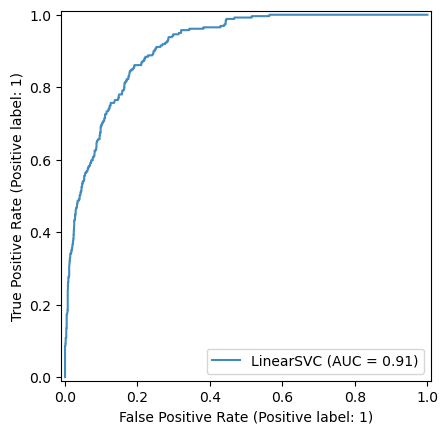

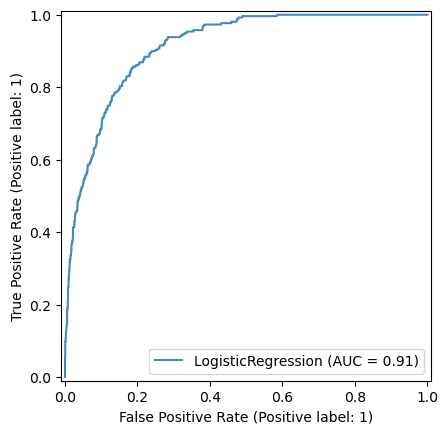

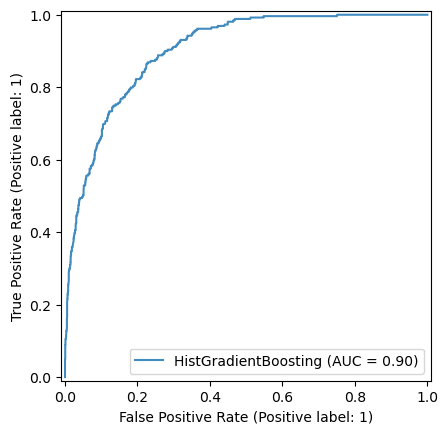

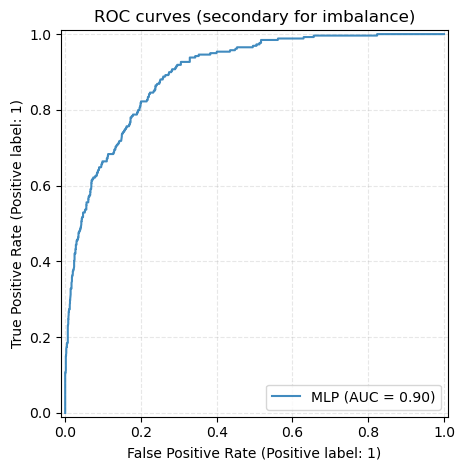

<Figure size 700x500 with 0 Axes>

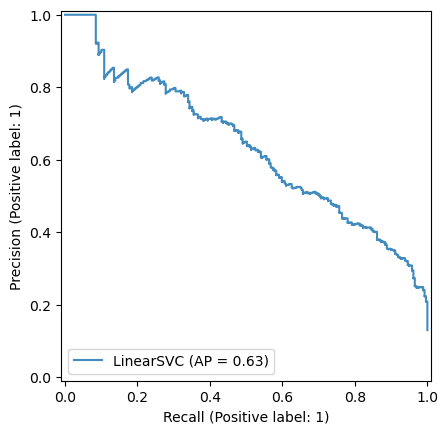

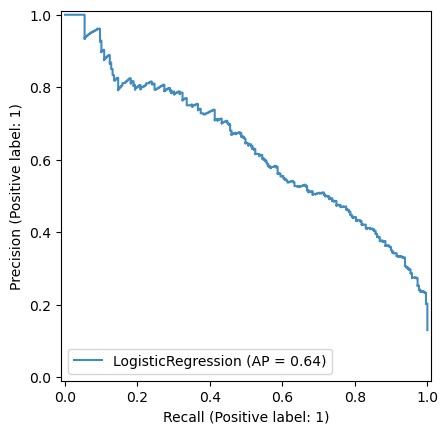

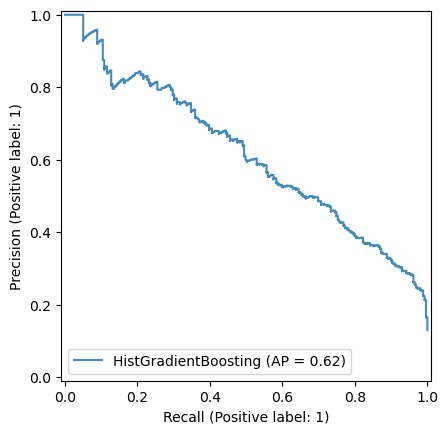

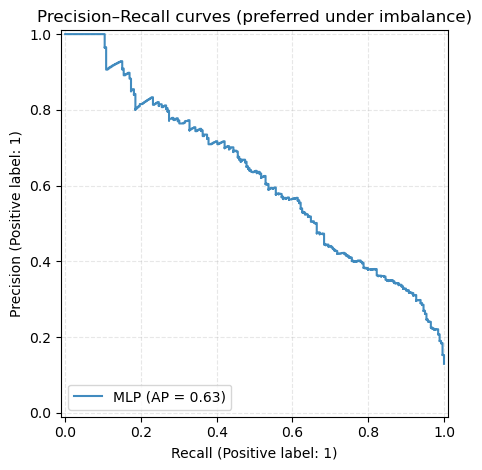

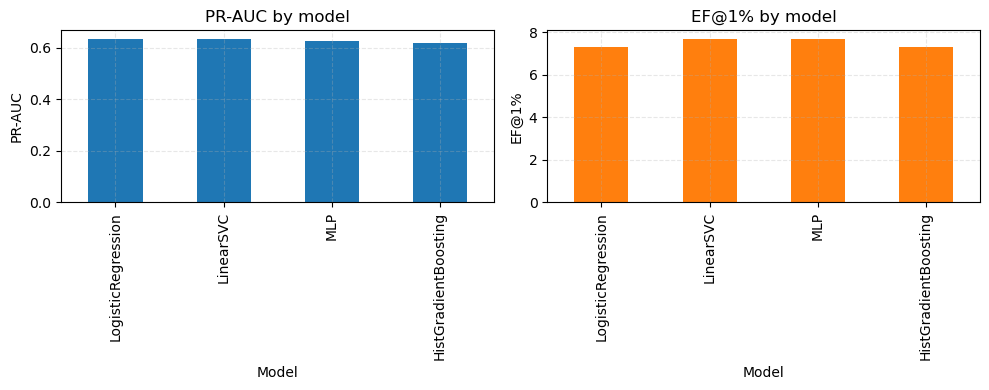

<Figure size 460x460 with 0 Axes>

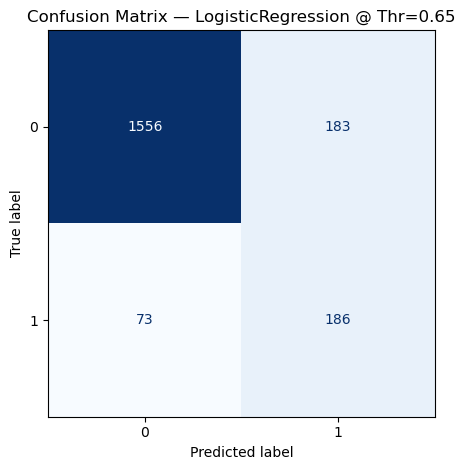

Saved metrics table to classification_model_metrics.csv


In [31]:
# -----------------------------------------------------------------------------
# Section 9: Compare models with figures and metrics table (robust to key names)
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay, confusion_matrix
)

# --- 9.1 Build a metrics table from `results` safely -------------------------
# Map keys flexibly in case earlier cells used different names
def get_val(d, *keys, default=None):
    # Return the first present key from a list of alternatives
    for k in keys:
        if k in d:
            return d[k]
    return default

rows = []
for name, res in results.items():
    rows.append({
        'Model': name,
        'PR_AUC': get_val(res, 'PR_AUC', 'pr_auc', default=np.nan),
        'ROC_AUC': get_val(res, 'ROC_AUC', 'roc_auc', default=np.nan),
        'F1@0.5': get_val(res, 'F1@0.5', 'f1_default', default=np.nan),
        'F1@best': get_val(res, 'F1@best', 'f1_at_best_thr', default=np.nan),
        'EF@1%': get_val(res, 'EF@1%', 'ef_at_1pct', default=np.nan),
        'BestThr': get_val(res, 'BestThr', 'best_threshold', default=np.nan),
        'BestParams': get_val(res, 'best_params', default={})
    })

metrics_df = pd.DataFrame(rows).sort_values('PR_AUC', ascending=False).reset_index(drop=True)
print("\nModel comparison (sorted by PR_AUC):")
print(metrics_df)

# --- 9.2 Recompute y_prob per model for curves (use calibrated if available) --
def get_model_for_prob(res_item):
    # Prefer calibrated estimator when present; else raw
    if res_item.get('use_calibrated', False) and res_item.get('calibrated_estimator', None) is not None:
        return res_item['calibrated_estimator']
    return res_item.get('raw_estimator', None)

# Collect probabilities for plotting (recompute as Section 8 didn’t store y_prob)
probs = {}
for name, res in results.items():
    clf = get_model_for_prob(res)
    if clf is None:
        continue
    if hasattr(clf, "predict_proba"):
        probs[name] = clf.predict_proba(X_test_scaled)[:, 1]
    else:
        probs[name] = clf.decision_function(X_test_scaled)

# --- 9.3 ROC curves (secondary in imbalance) ---------------------------------
plt.figure(figsize=(7, 5))
for name, y_prob in probs.items():
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, alpha=0.85)
plt.title('ROC curves (secondary for imbalance)')
plt.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 9.4 Precision–Recall curves (primary for imbalance) ---------------------
plt.figure(figsize=(7, 5))
for name, y_prob in probs.items():
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=name, alpha=0.85)
plt.title('Precision–Recall curves (preferred under imbalance)')
plt.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 9.5 Bar chart: PR-AUC and EF@1% side-by-side for quick comparison -------
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
metrics_df.plot(kind='bar', x='Model', y='PR_AUC', ax=ax[0], color='#1f77b4', legend=False)
ax[0].set_title('PR-AUC by model')
ax[0].set_ylabel('PR-AUC')
ax[0].grid(True, ls='--', alpha=0.3)

metrics_df.plot(kind='bar', x='Model', y='EF@1%', ax=ax[1], color='#ff7f0e', legend=False)
ax[1].set_title('EF@1% by model')
ax[1].set_ylabel('EF@1%')
ax[1].grid(True, ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 9.6 Confusion matrix for the best model at its tuned threshold ----------
# Identify best model by PR-AUC (first row after sorting)
best_name = metrics_df.iloc[0]['Model']
best_thr = float(metrics_df.iloc[0]['BestThr'])

# Generate hard labels at tuned threshold
y_prob_best = probs[best_name]
y_best = (y_prob_best >= best_thr).astype(int)

cm = confusion_matrix(y_test, y_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(4.6, 4.6))
disp.plot(cmap='Blues', values_format='d', colorbar=False)
plt.title(f'Confusion Matrix — {best_name} @ Thr={best_thr:.2f}')
plt.tight_layout()
plt.show()

# --- 9.7 Save metrics table ---------------------------------------------------
metrics_df.to_csv('classification_model_metrics.csv', index=False)
print("Saved metrics table to classification_model_metrics.csv")


In [33]:
# -----------------------------------------------------------------------------
# Section 10: Predict labels for the full dataset (incl. duplicates) with best model
# Idempotent and robust: overwrites existing prediction columns and reorders them
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd

# 1) Scale full descriptor matrix with train-fitted scaler
X_all = desc_df_all.values                                  # Full descriptor matrix
X_all_scaled = scaler.transform(X_all)                      # Use the fitted scaler

# 2) Choose the estimator to produce probabilities
model_to_use = best_estimator                              # Calibrated model if available was saved as best_estimator

# 3) Get scores/probabilities
if hasattr(model_to_use, "predict_proba"):
    y_all_prob = model_to_use.predict_proba(X_all_scaled)[:, 1]  # Positive class probability
else:
    y_all_prob = model_to_use.decision_function(X_all_scaled)    # Decision scores

# 4) Sanity checks on shapes
if len(y_all_prob) != len(df_all):
    raise ValueError(f"Length mismatch: preds={len(y_all_prob)} vs df_all={len(df_all)}")

# 5) Apply tuned threshold to produce hard labels
y_all_pred = (y_all_prob >= best_threshold).astype(int)

# 6) Overwrite or create prediction columns without using insert (avoids duplicate-name error)
df_all['Predicted_Prob'] = y_all_prob
df_all['Predicted_Label'] = y_all_pred

# 7) Reorder columns so predictions sit immediately after 'label'
if 'label' in df_all.columns:
    cols = list(df_all.columns)
    # Remove prediction cols and reinsert after 'label'
    for c in ['Predicted_Prob', 'Predicted_Label']:
        if c in cols:
            cols.remove(c)
    insert_at = cols.index('label') + 1
    cols[insert_at:insert_at] = ['Predicted_Prob', 'Predicted_Label']
    df_all = df_all[cols]

# 8) Save full predictions
df_all.to_csv('full_classification_predictions.csv', index=False)
print("Saved full predictions to full_classification_predictions.csv")


Saved full predictions to full_classification_predictions.csv


In [36]:
# -----------------------------------------------------------------------------
# Section 11: Display the final results
# -----------------------------------------------------------------------------
print(f"\nBest model selected: {best_name}")
print(metrics_df.head(len(metrics_df)))
print(df_all[['Predicted_Prob', 'Predicted_Label']].head())

# Also save top-N by probability for quick triage
topN = 20  # adjust as needed
df_top = df_all.sort_values('Predicted_Prob', ascending=False).head(topN).copy()
df_top = df_top.iloc[:, [0, 1, 2, 3, 5, 6]]
df_top.to_csv('top_predicted_actives.csv', index=False)
print(f"\nSaved top {topN} predicted actives to top_predicted_actives.csv")


Best model selected: LogisticRegression
                  Model    PR_AUC   ROC_AUC    F1@0.5   F1@best     EF@1%  \
0    LogisticRegression  0.636283  0.912508  0.555701  0.592357  7.308271   
1             LinearSVC  0.634920  0.911493  0.552699  0.587849  7.714286   
2                   MLP  0.625599  0.896597  0.527591  0.589981  7.714286   
3  HistGradientBoosting  0.617281  0.901915  0.562319  0.578275  7.308271   

   BestThr                                         BestParams  
0     0.65     {'C': 0.125, 'l1_ratio': 0.0, 'penalty': 'l1'}  
1     0.66                                       {'C': 0.125}  
2     0.77  {'alpha': 0.001, 'hidden_layer_sizes': (128,),...  
3     0.61  {'learning_rate': 0.03, 'max_iter': 200, 'max_...  
   Predicted_Prob  Predicted_Label
0        0.877871                1
1        0.622587                0
2        0.047486                0
3        0.203979                0
4        0.579539                0

Saved top 20 predicted actives to top_pred